Import packages

In [1]:
# Numerical Operations
import math
import numpy as np

# Progress bar
from tqdm import tqdm

# Pytorch
import torch

# Plotting learning curve
from matplotlib import pyplot as plt

Dataset

Text(0, 0.5, 'z height (m)')

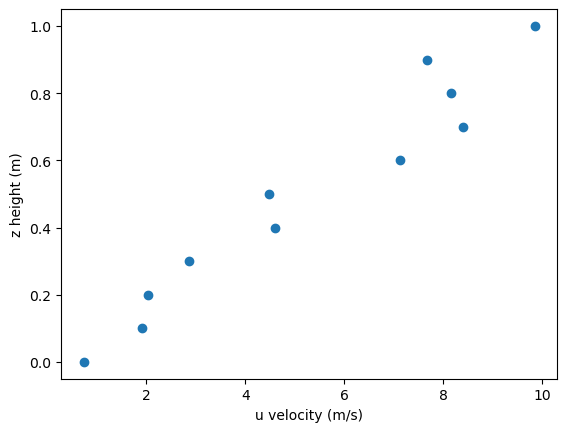

In [2]:
#Linear Couette flow
H=1
z=np.arange(0,1.1,0.1)
U=10
u=z*U/H+np.random.randn(len(z))
plt.scatter(u,z)
plt.xlabel("u velocity (m/s)")
plt.ylabel("z height (m)")

In [3]:
#Put datas into torch tensor
z=torch.tensor(z)
u=torch.tensor(u)

Model

In [4]:
#Linear model
def model(x,w,b):
    return w*x+b

Loss function

In [5]:
#Mean Square Error Loss
def loss_fn(x_p,y):
    loss_fn=(x_p-y)**2
    return loss_fn.mean()

Derivative of loss function

In [6]:
#Taking derivative by calculus
def grad_fn(x_p,x,y):
    dloss_dw=2*(x_p-y)*x
    dloss_db=2*(x_p-y)*1.0
    return torch.stack([dloss_dw.mean(), dloss_db.mean()])

Optimizer

In [7]:
#Gradient descent
def optim(params,lr,grad):
    
    params=params-lr*grad
    return params

In [8]:
'''Homework!!! Changing optimizer to this code, 
Additionally, implement L2 regularization code tAo achieve intermediate level'''
#optimizer=optim.SGD([XXXX], XXXX, XXXX)

'Homework!!! Changing optimizer to this code, \nAdditionally, implement L2 regularization code tAo achieve intermediate level'

Training loop

In [9]:
#Parameters update 
def training(x,y,params,n_epoch,lr):
    for epoch in range(1, n_epoch+1):
        w, b=params
        x_p=model(x,w,b)
        loss=loss_fn(x_p,y)
        grad=grad_fn(x_p,x,y)
        params=optim(params,lr,grad)
        '''Homework!!! Changing  optimize step to thiscode to achieve intermediate level'''
        #optimizer.zero_grad()
        #train_loss.backward()
        #optimizer.step()
        print('Epoch: %d, Loss: %f' %(epoch, loss))
    return params

Configuration

In [10]:
''' Homework!!! You have to fill the number in this block to achieve basic grade '''
params=torch.tensor([XX, XX]) # weight and bias, arbitrary number
config={
    "number epoch": XXXXX, # number of epoch, suggest from 100 to 50000
    "learning rate": XXXX, # learning rate, suggest from 1e-2 to 1e-5
    }

Training !

In [12]:
params=training(z,u,params,config["number epoch"],config["learning rate"])

Epoch: 1, Loss: 29.744841
Epoch: 2, Loss: 29.613803
Epoch: 3, Loss: 29.483425
Epoch: 4, Loss: 29.353704
Epoch: 5, Loss: 29.224637
Epoch: 6, Loss: 29.096219
Epoch: 7, Loss: 28.968448
Epoch: 8, Loss: 28.841321
Epoch: 9, Loss: 28.714833
Epoch: 10, Loss: 28.588983
Epoch: 11, Loss: 28.463766
Epoch: 12, Loss: 28.339180
Epoch: 13, Loss: 28.215221
Epoch: 14, Loss: 28.091886
Epoch: 15, Loss: 27.969172
Epoch: 16, Loss: 27.847076
Epoch: 17, Loss: 27.725595
Epoch: 18, Loss: 27.604725
Epoch: 19, Loss: 27.484463
Epoch: 20, Loss: 27.364807
Epoch: 21, Loss: 27.245753
Epoch: 22, Loss: 27.127298
Epoch: 23, Loss: 27.009439
Epoch: 24, Loss: 26.892174
Epoch: 25, Loss: 26.775498
Epoch: 26, Loss: 26.659410
Epoch: 27, Loss: 26.543905
Epoch: 28, Loss: 26.428982
Epoch: 29, Loss: 26.314638
Epoch: 30, Loss: 26.200868
Epoch: 31, Loss: 26.087671
Epoch: 32, Loss: 25.975043
Epoch: 33, Loss: 25.862982
Epoch: 34, Loss: 25.751485
Epoch: 35, Loss: 25.640548
Epoch: 36, Loss: 25.530169
Epoch: 37, Loss: 25.420346
Epoch: 38,

Plot the result

Text(0, 0.5, 'z height (m)')

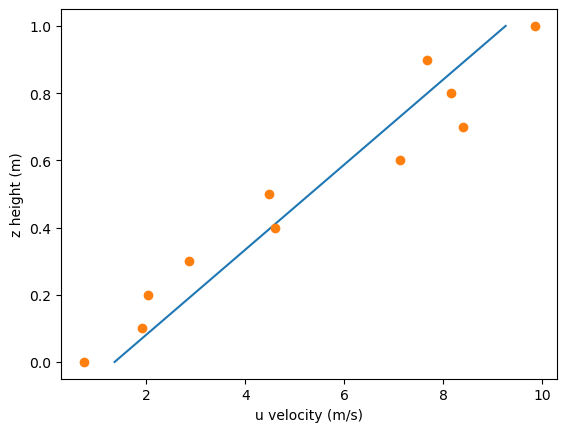

In [13]:
w,b=params
z_p=model(z,w,b)
fig=plt.figure(dpi=100)
plt.plot(z_p.detach().numpy(),z.detach().numpy())
plt.plot(u.numpy(),z.numpy(), 'o')
plt.xlabel("u velocity (m/s)")
plt.ylabel("z height (m)")